## **Validation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load BERT classifications 
predictions_elite = pd.read_csv('../data/anti_elitism_final_test_probabilities.csv')
predictions_people = pd.read_csv('../data/people_centrism_final_test_probabilities.csv')

In [3]:
predictions_elite.head()

,unique_id,sentence,prob_class0,prob_class1,label,predicted_label
0,497668_10,These are the very animals the CAP has been ig...,0.885247,0.114753,0,0
1,389043_4,The failure to award the Sakharov Prize to the...,0.102516,0.897484,1,1
2,390512_9,People who do not respect democratic values si...,0.218099,0.781901,0,1
3,307593_10,It reinforces the mutual respect and fairness ...,0.973451,0.026549,0,0
4,495437_10,We must invest and not forget that at present ...,0.994698,0.005302,0,0


In [4]:
predictions_elite = predictions_elite.rename(columns={
    'prob_class0': 'pred_non_anti_elitism',
    'prob_class1': 'pred_anti_elitism'
})

In [5]:
# Load dictionary classification
dictionary_elite = pd.read_csv('/Users/antoniagranser/Library/Mobile Documents/com~apple~CloudDocs/Documents/Master LMU/Master Thesis/text_analysis_ep_populism/dictionary_analysis/outputs/ep_anti_elitism_classified.csv')
dictionary_people = pd.read_csv('/Users/antoniagranser/Library/Mobile Documents/com~apple~CloudDocs/Documents/Master LMU/Master Thesis/text_analysis_ep_populism/dictionary_analysis/outputs/ep_people_centrism_classified.csv')    

In [6]:
dictionary_elite.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,sentence_pre,matched_word,category,matched_frame
0,1_16,1,16,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,A few bad apples must no longer ruin the reput...,bad apples must longer ruin reputation us,bad apples,bad,bad apples
1,11_9,11,9,Marie Dauchy,ID,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,So forget about your useless organs and be les...,forget useless organs less forgiving corrupt p...,politicians,bad,betray
2,34_6,34,6,Vlad Gheorghe,Renew,2024-04-25,3. Pre-enlargement reforms and policy reviews ...,9,2024,Billions that they are circulating a lot even ...,billions circulating lot even country european...,politicians,bad,traitors
3,224_14,224,14,Eero Heinäluoma,S&D,2024-04-24,12. The sixth Anti-Money Laundering Directive ...,9,2024,This is a good day for honest actors and busin...,good day honest actors business bad day oligar...,oligarchs,bad,bad
4,237_7,237,7,Martin Schirdewan,The Left,2024-04-24,12. The sixth Anti-Money Laundering Directive ...,9,2024,"Only in this way can corruption, organized cri...",way corruption organized crime oligarchs serio...,oligarchs,bad,corruption


In [7]:
# Create binary label for dictionary predictions

dictionary_elite['matched_frame'] = dictionary_elite['matched_frame'].apply(lambda x: 0 if pd.isna(x) else 1)

dictionary_people['matched_frame'] = dictionary_people['matched_frame'].apply(lambda x: 0 if pd.isna(x) else 1)

In [8]:
# Load full dataset
ep = pd.read_csv('/Users/antoniagranser/Library/Mobile Documents/com~apple~CloudDocs/Documents/Master LMU/Master Thesis/text_analysis_ep_populism/dictionary_analysis/data/parllaw_preprocessed.csv')

In [9]:
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,sentence_pre
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",madam president dear colleagues
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,politics must sale
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,cannot political decisions parliament bought l...
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",whether qatar russia china especially extreme ...
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",even threshold criminal law bribery repeated s...


In [10]:
# Merge for validation

val_elite = pd.merge(ep, predictions_elite, on=['unique_id', 'sentence'], how='right')

val_people = pd.merge(ep, predictions_people, on=['unique_id', 'sentence'], how='right')

In [11]:
val_elite.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,sentence_pre,pred_non_anti_elitism,pred_anti_elitism,label,predicted_label
0,497668_10,497668,10,Josu Ortuondo Larrea,Greens/EFA,2001-05-03,5. Vote,5,2001,These are the very animals the CAP has been ig...,animals cap ignoring years must promote order ...,0.885247,0.114753,0,0
1,389043_4,389043,4,Jean-Luc Mélenchon,GUE/NGL,2011-02-03,9. Explanations of vote,7,2011,The failure to award the Sakharov Prize to the...,failure award sakharov prize north african opp...,0.102516,0.897484,1,1
2,390512_9,390512,9,Edvard Kožušník,ECR,2011-01-19,12. Situation in Belarus,7,2011,People who do not respect democratic values si...,people respect democratic values simply place ...,0.218099,0.781901,0,1
3,307593_10,307593,10,Sandrine Bélier,Greens/EFA,2013-09-11,16. Access to genetic resources and the fair a...,7,2013,It reinforces the mutual respect and fairness ...,reinforces mutual respect fairness fellow citi...,0.973451,0.026549,0,0
4,495437_10,495437,10,Dorette Corbey,S&D,2001-09-04,10. Outcome of the Bonn conference on climate ...,5,2001,We must invest and not forget that at present ...,must invest forget present two billion people ...,0.994698,0.005302,0,0


In [12]:
# Merge again with dictionary predictions for comparison
shared_cols = val_elite.columns.intersection(dictionary_elite.columns).tolist()
val_comp_elite = pd.merge(val_elite, dictionary_elite, on=shared_cols, how='left')

val_comp_elite.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,sentence_pre,pred_non_anti_elitism,pred_anti_elitism,label,predicted_label,matched_word,category,matched_frame
0,497668_10,497668,10,Josu Ortuondo Larrea,Greens/EFA,2001-05-03,5. Vote,5,2001,These are the very animals the CAP has been ig...,animals cap ignoring years must promote order ...,0.885247,0.114753,0,0,NaN,NaN,NaN
1,389043_4,389043,4,Jean-Luc Mélenchon,GUE/NGL,2011-02-03,9. Explanations of vote,7,2011,The failure to award the Sakharov Prize to the...,failure award sakharov prize north african opp...,0.102516,0.897484,1,1,eurocrats,bad,1.0
2,390512_9,390512,9,Edvard Kožušník,ECR,2011-01-19,12. Situation in Belarus,7,2011,People who do not respect democratic values si...,people respect democratic values simply place ...,0.218099,0.781901,0,1,NaN,NaN,NaN
3,307593_10,307593,10,Sandrine Bélier,Greens/EFA,2013-09-11,16. Access to genetic resources and the fair a...,7,2013,It reinforces the mutual respect and fairness ...,reinforces mutual respect fairness fellow citi...,0.973451,0.026549,0,0,NaN,NaN,NaN
4,495437_10,495437,10,Dorette Corbey,S&D,2001-09-04,10. Outcome of the Bonn conference on climate ...,5,2001,We must invest and not forget that at present ...,must invest forget present two billion people ...,0.994698,0.005302,0,0,NaN,NaN,NaN


In [13]:
print(len(val_elite), len(val_comp_elite))

424 424


In [14]:

shared_cols = val_people.columns.intersection(dictionary_people.columns).tolist()
val_comp_people = pd.merge(val_people, dictionary_people, on=shared_cols, how='left')
val_comp_people.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,sentence_pre,prob_non_people_centrism,prob_people_centrism,label,predicted_label,matched_word,category,matched_frame
0,501450_24,501450,24,Marieke Sanders-Ten Holte,ALDE,2000-11-30,1. Safety at sea,5,2000,"That is bad for the people, the sea, the envir...",bad people sea environment sector image,0.862901,0.137099,0,0,NaN,NaN,NaN
1,505431_13,505431,13,Salafranca Sánchez-Neyra,PPE,2000-06-14,4. Security and defence,5,2000,"The citizens of the Union, represented by Parl...",citizens union represented parliament increasi...,0.524296,0.475704,1,1,citizens,good,1.0
2,48433_9,48433,9,Heléne Fritzon,S&D,2020-01-13,14. Cross-border organised crime and its impac...,9,2020,That's right.,right,0.985984,0.014016,0,0,NaN,NaN,NaN
3,103699_7,103699,7,Steeve Briois,ENF,2016-10-26,6.2. General budget of the European Union for ...,8,2016,I therefore voted against this text.,therefore voted text,0.987509,0.012491,0,0,NaN,NaN,NaN
4,504000_7,504000,7,Ilka Schröder,Greens/EFA,2000-09-06,5. Votes,5,2000,"In saying these things, he is playing into the...",saying things playing hands aim drive millions...,0.755673,0.244327,0,0,NaN,NaN,NaN


In [15]:
val_comp_elite['matched_frame'] = val_comp_elite['matched_frame'].fillna(0).astype(int)

val_comp_people['matched_frame'] = val_comp_people['matched_frame'].fillna(0).astype(int)

In [16]:
# Save the merged datasets
val_comp_elite.to_csv('../outputs/validation_elite_comp_dict.csv', index=False)
val_comp_people.to_csv('../outputs/validation_people_comp_dict.csv', index=False)

### Compare predictions

#### Anti-elitism

In [46]:
from sklearn.metrics import classification_report, f1_score

y_true = val_comp_elite['label']

# Dictionary approach
y_pred_dict = val_comp_elite['matched_frame']
print("Dictionary approach:")
print(classification_report(y_true, y_pred_dict))

# Transformer approach
y_pred_transformer = val_comp_elite['predicted_label']
print("\nTransformer approach:")
print(classification_report(y_true, y_pred_transformer))

Dictionary approach:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       345
           1       0.47      0.54      0.50        79

    accuracy                           0.80       424
   macro avg       0.68      0.70      0.69       424
weighted avg       0.81      0.80      0.81       424


Transformer approach:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       345
           1       0.64      0.61      0.62        79

    accuracy                           0.86       424
   macro avg       0.78      0.76      0.77       424
weighted avg       0.86      0.86      0.86       424



In [47]:
report_dict = classification_report(y_true, y_pred_dict, output_dict=True)
report_transformer = classification_report(y_true, y_pred_transformer, output_dict=True)

comparison = pd.DataFrame({
    'Dictionary': pd.Series(report_dict['1']),  # metrics for class 1
    'Transformer': pd.Series(report_transformer['1'])
}).round(2)

print(comparison)

           Dictionary  Transformer
precision        0.47         0.64
recall           0.54         0.61
f1-score         0.50         0.62
support         79.00        79.00


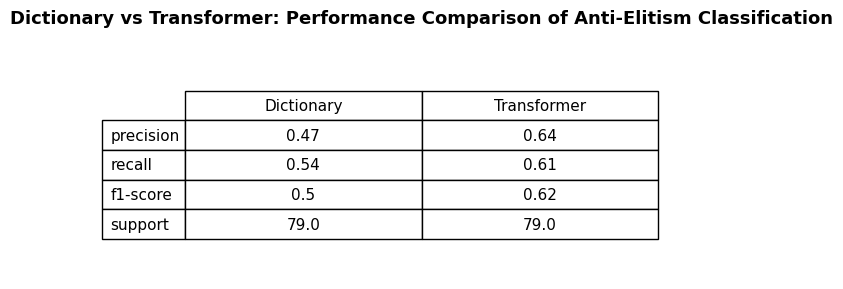

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

table = ax.table(
    cellText=comparison.values.round(2),
    rowLabels=comparison.index,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title('Dictionary vs Transformer: Performance Comparison of Anti-Elitism Classification', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/tables/dict_vs_transformer_comparison_anti_elitism.png', dpi=150, bbox_inches='tight')
plt.show()

#### People-centrism

In [50]:

y_true = val_comp_people['label']

# Dictionary approach
y_pred_dict = val_comp_people['matched_frame']
print("Dictionary approach:")
print(classification_report(y_true, y_pred_dict))

# Transformer approach
y_pred_transformer = val_comp_people['predicted_label']
print("\nTransformer approach:")
print(classification_report(y_true, y_pred_transformer))

Dictionary approach:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       344
           1       0.43      0.56      0.49        80

    accuracy                           0.78       424
   macro avg       0.66      0.70      0.67       424
weighted avg       0.80      0.78      0.79       424


Transformer approach:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       344
           1       0.73      0.69      0.71        80

    accuracy                           0.89       424
   macro avg       0.83      0.81      0.82       424
weighted avg       0.89      0.89      0.89       424



In [51]:
report_dict = classification_report(y_true, y_pred_dict, output_dict=True)
report_transformer = classification_report(y_true, y_pred_transformer, output_dict=True)

comparison = pd.DataFrame({
    'Dictionary': pd.Series(report_dict['1']),  # metrics for class 1
    'Transformer': pd.Series(report_transformer['1'])
}).round(2)

print(comparison)

           Dictionary  Transformer
precision        0.43         0.73
recall           0.56         0.69
f1-score         0.49         0.71
support         80.00        80.00


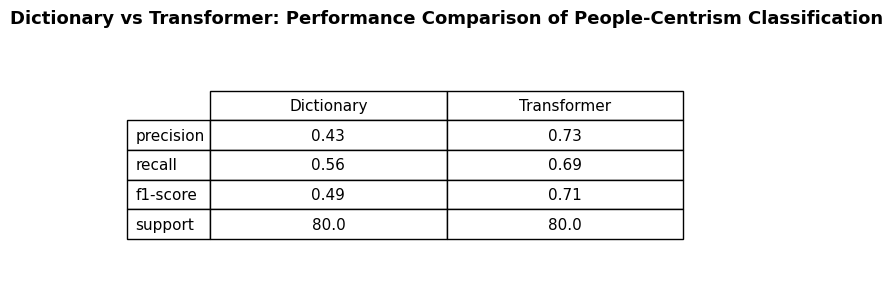

In [52]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

table = ax.table(
    cellText=comparison.values.round(2),
    rowLabels=comparison.index,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title('Dictionary vs Transformer: Performance Comparison of People-Centrism Classification', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/tables/dict_vs_transformer_comparison_people_centrism.png', dpi=150, bbox_inches='tight')
plt.show()

### **Validation of Populism Dimension (tranformer & combined transformer)**

In [2]:
# Load dataset with all predictions
ep_pred = pd.read_csv('../data/ep_speeches_classified_total.csv')
ep_pred.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


In [3]:
# Create column of anti-elitism & people-centrism combined 

ep_pred['populism_combined'] = ((ep_pred['anti_elitism_binary'] == 1) & (ep_pred['people_centrism_binary'] == 1)).astype(int)

#### Validation

In [8]:
# Load hand-coded data
annotations_populism = pd.read_excel('/Users/antoniagranser/Library/Mobile Documents/com~apple~CloudDocs/Documents/Master LMU/Master Thesis/text_analysis_ep_populism/dictionary_analysis/outputs/annotated_sample_populism.xlsx')
annotations_populism.head()

,unique_id,speech_id,sentence_id,sentence,populist
0,27_2,27,2,"Firstly, we do not want a revision of the trea...",0
1,304_1,304,1,"Mr President, ordinary people across Europe ar...",0
2,573_8,573,8,"I believe they are, and I believe that today t...",0
3,3018_7,3018,7,"And so, President Lagarde, the criminal polici...",0
4,3101_6,3101,6,"Ordinary people are caught in the vice, being ...",0


In [9]:
# Rename columns for clarity
annotations_populism = annotations_populism.rename(columns={
    'populist': 'label'
})

In [10]:
# Split data into same train/dev/test split as for training
from sklearn.model_selection import train_test_split

def split_data(
    data: pd.DataFrame,
    test_size: float = 0.15,
    dev_size: float = 0.15,
    seed: int = 42,
):

# Split of test set
    train_dev, test = train_test_split(
        data, test_size=test_size, random_state=seed, stratify=data['label']
    )

# Split of dev set from remaining df
    train, dev = train_test_split(
        train_dev, test_size=dev_size / (1 - test_size), random_state=seed, stratify=train_dev['label']
    )

# Return the three datasets
    return train, dev, test

train, dev, test = split_data(annotations_populism, seed=42)

In [11]:
# Merge for validation
shared_cols = ep_pred.columns.intersection(test.columns).tolist()
ep_pred = pd.merge(ep_pred, test, on=shared_cols, how='right')
ep_pred.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,...,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary,populism_combined,label
0,330829_8,330829,8,Charles Tannock,ECR,2012-12-12,8. Explanations of vote,7,2012,"In particular, restraint must be applied to th...",...,0.955522,1,0.985116,0.014884,0,0.011011,0.988989,1,0,0
1,369694_52,369694,52,President of the Commission,-,2011-09-28,3. State of the Union (debate),7,2011,There is one thing that I would like to admit ...,...,0.680852,1,0.948588,0.051412,0,0.981813,0.018187,0,0,0
2,390512_9,390512,9,Edvard Kožušník,ECR,2011-01-19,12. Situation in Belarus,7,2011,People who do not respect democratic values si...,...,0.781902,1,0.605424,0.394576,0,0.803538,0.196462,0,0,0
3,39278_12,39278,12,Ramona Strugariu,Renew,2021-03-09,10. Activities of the European Ombudsman – ann...,9,2021,Being a high ranking official entails responsi...,...,0.023055,0,0.993025,0.006975,0,0.994524,0.005477,0,0,0
4,283898_5,283898,5,Véronique Mathieu,PPE,2014-02-25,6.10. Freezing and confiscation of proceeds of...,7,2014,And these millions of euros that they accumula...,...,0.958726,1,0.004405,0.995595,1,0.001842,0.998158,1,1,1


In [12]:
from sklearn.metrics import classification_report, f1_score

y_true = ep_pred['label']

# Transformer populism
y_pred_p1 = ep_pred['populism_binary']
print("Transformer approach:")
print(classification_report(y_true, y_pred_p1))

# Combined populism
y_pred_p2 = ep_pred['populism_combined']
print("Combined approach:")
print(classification_report(y_true, y_pred_p2))

Transformer approach:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       375
           1       0.51      0.78      0.61        49

    accuracy                           0.89       424
   macro avg       0.74      0.84      0.77       424
weighted avg       0.92      0.89      0.90       424

Combined approach:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       375
           1       0.70      0.86      0.77        49

    accuracy                           0.94       424
   macro avg       0.84      0.90      0.87       424
weighted avg       0.95      0.94      0.94       424



In [16]:
report_transformer = classification_report(y_true, y_pred_p1, output_dict=True)
report_combined = classification_report(y_true, y_pred_p2, output_dict=True)

comparison = pd.DataFrame({
    'Transformer': pd.Series(report_transformer['1']),  # metrics for class 1
    'Combined': pd.Series(report_combined['1'])
}).round(2)

print(comparison)

           Transformer  Combined
precision         0.51      0.70
recall            0.78      0.86
f1-score          0.61      0.77
support          49.00     49.00


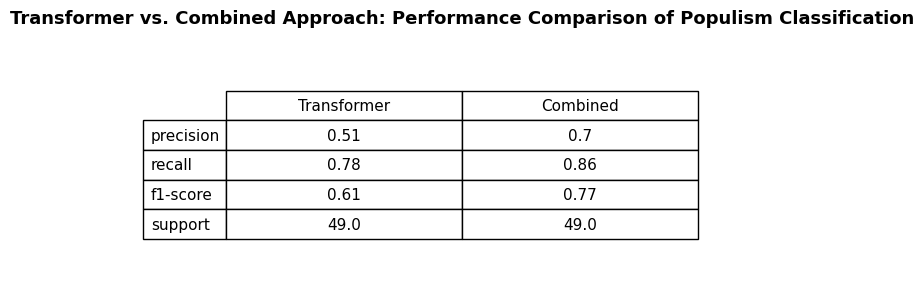

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

table = ax.table(
    cellText=comparison.values.round(2),
    rowLabels=comparison.index,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.title('Transformer vs. Combined Approach: Performance Comparison of Populism Classification', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/tables/transformer_vs_combined_comparison_populism.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
ep_pred['populism_binary'].value_counts()

populism_binary
0    349
1     75
Name: count, dtype: int64

In [14]:
ep_pred['populism_combined'].value_counts()

populism_combined
0    364
1     60
Name: count, dtype: int64

In [15]:
ep_pred['label'].value_counts()

label
0    375
1     49
Name: count, dtype: int64